In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

In [2]:
df1 = pd.read_csv('TrafficLabelling /Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [3]:
df1.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow ID                       225745 non-null  object 
 1    Source IP                    225745 non-null  object 
 2    Source Port                  225745 non-null  int64  
 3    Destination IP               225745 non-null  object 
 4    Destination Port             225745 non-null  int64  
 5    Protocol                     225745 non-null  int64  
 6    Timestamp                    225745 non-null  object 
 7    Flow Duration                225745 non-null  int64  
 8    Total Fwd Packets            225745 non-null  int64  
 9    Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets   225745 non-null  int64  
 11   Total Length of Bwd Packets  225745 non-null  int64  
 12   Fwd Packet Length Max        225745 non-nul

In [5]:
df1.describe()

/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.000000,225745.00000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,38257.568402,8879.61946,7.600288,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,23057.302075,19754.64740,3.881586,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.000000,0.00000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,18990.000000,80.00000,6.000000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,49799.000000,80.00000,6.000000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,58296.000000,80.00000,6.000000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65534.000000,65532.00000,17.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [6]:
df1[' Label'].value_counts()

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Pick a machine learning methodology and justify your choice

My machine learning methodology is to first encode the label to 0 for benign and 1 for everything else. Then I want to get rid of NULL records and INF records as they don't make up a large portion of the dataset. I also want to one hot encode the most import ports as they probably have something to contribute to the scenario. I will also display some histograms to gain more info on the dataset. I'll pick a few classifier algorithms to try and pick the best performing one for this dataset on the other datasets.

In [7]:
def onehot_label(df):
    df[' Label'] = df[' Label'].apply(lambda label: 1 if label != 'BENIGN' else 0)
    return df

In [8]:
new_df1 = onehot_label(df1)

In [9]:
new_df1[' Label'].value_counts()

 Label
1    128027
0     97718
Name: count, dtype: int64

In [10]:
df1.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [11]:
df1[' Destination Port'].value_counts()[:20]

 Destination Port
80       136951
53        31950
443       13485
8080        510
123         362
22          342
137         274
389         261
88          173
21          167
465         147
139         100
3268         91
0            54
138          53
445          48
135          23
49666        23
5353         16
49671        12
Name: count, dtype: int64

In [12]:
df1[' Source Port'].value_counts()[:20]

 Source Port
80       33528
443       6419
123        362
137        274
22         156
21          86
0           54
138         53
139         31
389         26
39524       22
60406       20
48318       20
60883       20
61399       19
56540       18
49666       18
60340       17
62146       17
61407       17
Name: count, dtype: int64

In [13]:
important_ports = {
    20: "FTP Data",
    21: "FTP Control",
    22: "SSH",
    23: "Telnet",
    25: "SMTP",
    53: "DNS",
    80: "HTTP",
    110: "POP3",
    119: "NNTP",
    123: "NTP",
    137: "NetBIOS",
    143: "IMAP",
    161: "SNMP",
    194: "IRC",
    443: "HTTPS",
    8080: "HTTP Alt"
}

In [14]:
def map_ports_to_services(df, port_column, new_column='service'):
    df[new_column] = df[port_column].apply(lambda port: important_ports.get(port,'other ports'))
    return df

In [15]:
df1 = map_ports_to_services(df1, ' Source Port', 'New Source Port')

In [16]:
df1 = map_ports_to_services(df1, ' Destination Port', 'New Destination Port')

In [17]:
df1['New Source Port'].value_counts()

New Source Port
other ports    184919
HTTP            33528
HTTPS            6419
NTP               362
NetBIOS           274
SSH               156
FTP Control        86
DNS                 1
Name: count, dtype: int64

In [18]:
df1[' Source Port'].value_counts()[0:15]

 Source Port
80       33528
443       6419
123        362
137        274
22         156
21          86
0           54
138         53
139         31
389         26
39524       22
60406       20
48318       20
60883       20
61399       19
Name: count, dtype: int64

In [19]:
df1.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [20]:
#drop = [' Source Port', ' Destination Port', ]
drop = ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Timestamp']

df1.drop(columns=drop, inplace=True)

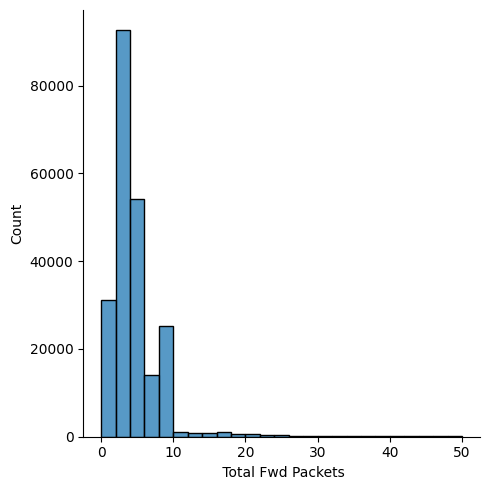

In [21]:
sns.displot(df1[' Total Fwd Packets'], binwidth=2, binrange=[0, 50])

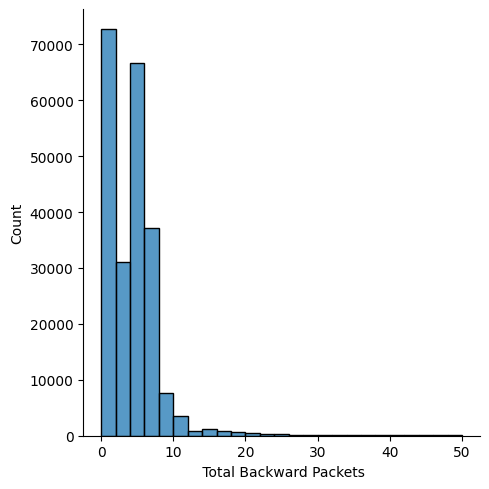

In [22]:
sns.displot(df1[' Total Backward Packets'], binwidth=2, binrange=[0, 50])

<Axes: xlabel='New Source Port', ylabel='count'>

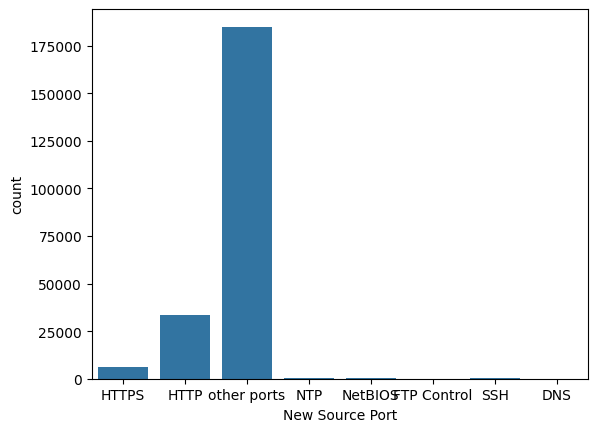

In [23]:
sns.countplot(data=df1, x='New Source Port')

<Axes: xlabel='New Destination Port', ylabel='count'>

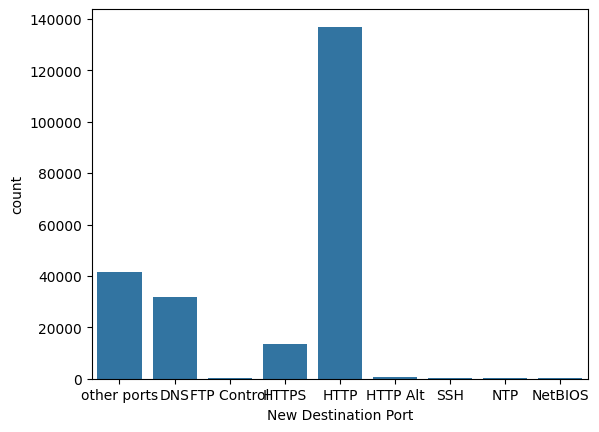

In [24]:
sns.countplot(data=df1, x='New Destination Port')

In [25]:
def encode_onehot(_df, _f):
    _df2 = pd.get_dummies(_df[_f], prefix=_f, prefix_sep=' - ', dtype=int)
    _df3 = pd.concat([_df, _df2], axis=1)
    _df3 = _df3.drop([_f], axis=1)
    return _df3

In [26]:
df1.columns

Index([' Protocol', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', 'FIN Flag

In [27]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Protocol                     225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [28]:
df1 = encode_onehot(df1, 'New Source Port')
df1 = encode_onehot(df1, 'New Destination Port')


In [29]:
clean_df1 = df1.dropna()

In [30]:
print(np.isinf(clean_df1.values).any(axis=1).sum())

30


In [31]:
def inf_handler(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.replace([float('inf'), float('-inf')], np.nan, inplace=True)
    null_index = df.loc[df.isnull().any(axis=1)].index
    df.drop(index=null_index, axis=1, inplace=True)
    df = df.reset_index()
    return df


In [32]:
clean_df1 = inf_handler(clean_df1)

In [33]:
print(np.isinf(clean_df1.values).any(axis=1).sum())

0


In [34]:
clean_df1.columns

Index(['index', ' Protocol', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', 

In [35]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


In [36]:
rfModel = RandomForestClassifier()
dtModel = DecisionTreeClassifier()
knModel = KNeighborsClassifier()


In [37]:
def eval(model, df):
    kfold = KFold(n_splits = 10)
    X = df.loc[:, df.columns != ' Label'].values
    y = df.loc[:, df.columns == ' Label'].values.ravel()
    Accuracies = cross_val_score(model,X, y,cv=kfold, scoring='accuracy', n_jobs=4)
    print(f'Accuracies: {Accuracies}\n')
    print(f'10-fold cross-validation accuracy is {np.mean(Accuracies):.3f} {chr(177)}{np.std(Accuracies):.4f}')

In [38]:
eval(rfModel, clean_df1)

Accuracies: [0.99982279 1.         0.9999557  0.9999557  0.99982278 0.9999557
 0.9999557  0.99991139 0.99871517 0.99645563]

10-fold cross-validation accuracy is 0.999 ±0.0011


In [39]:
eval(dtModel, clean_df1)

Accuracies: [0.97098175 1.         1.         0.99991139 0.99968987 0.9999557
 0.9999557  0.99991139 0.94010013 0.99601258]

10-fold cross-validation accuracy is 0.991 ±0.0189


In [40]:
eval(knModel, clean_df1)

Accuracies: [0.96043771 0.99401887 0.99663285 0.99734172 0.99574675 0.99415179
 0.99450622 0.99357583 0.98887954 0.98670861]

10-fold cross-validation accuracy is 0.990 ±0.0104


In [41]:
datasets = ['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
            'Friday-WorkingHours-Morning.pcap_ISCX.csv',
            'Monday-WorkingHours.pcap_ISCX.csv',
            'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
            'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
            'Tuesday-WorkingHours.pcap_ISCX.csv',
            'Wednesday-workingHours.pcap_ISCX.csv']

In [42]:
for dataset in datasets:
    print("Dataset: " + dataset)
    #df = pd.read_csv('TrafficLabelling /' + dataset)
    try: 
        df = pd.read_csv('TrafficLabelling /' + dataset, encoding='utf-8')
    except:
        df = pd.read_csv('TrafficLabelling /' + dataset, encoding='cp1252')
    new_df = onehot_label(df1)
    map_ports_to_services(df, ' Source Port', 'New Source Port')
    map_ports_to_services(df, ' Destination Port', 'New Destination Port')
    drop = ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Timestamp']
    rfModel = RandomForestClassifier(n_jobs=4)
    df.drop(columns=drop, inplace=True)
    df = encode_onehot(df, 'New Source Port')
    df = encode_onehot(df, 'New Destination Port')
    clean_df = df.dropna()
    clean_df = inf_handler(clean_df)
    eval(rfModel, clean_df)
    print("\n")

Dataset: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Accuracies: [0.99972038 0.99993009 1.         0.99982524 1.         1.
 1.         1.         0.99972037 0.99986018]

10-fold cross-validation accuracy is 1.000 ±0.0001


Dataset: Friday-WorkingHours-Morning.pcap_ISCX.csv
Accuracies: [1.         0.99994762 1.         1.         1.         1.
 1.         0.99989524 0.99994762 1.        ]

10-fold cross-validation accuracy is 1.000 ±0.0000


Dataset: Monday-WorkingHours.pcap_ISCX.csv
Accuracies: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

10-fold cross-validation accuracy is 1.000 ±0.0000


Dataset: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Accuracies: [1.         0.99996533 0.99947989 0.99982663 0.99996533 1.
 1.         0.99993065 1.         1.        ]

10-fold cross-validation accuracy is 1.000 ±0.0002


Dataset: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35222/3768493498.py:7: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('TrafficLabelling /' + dataset, encoding='cp1252')


Accuracies: [0.99935385 0.99964754 0.99970628 0.99694531 0.98801621 0.99812019
 1.         1.         1.         1.        ]

10-fold cross-validation accuracy is 0.998 ±0.0035


Dataset: Tuesday-WorkingHours.pcap_ISCX.csv
Accuracies: [0.99984293 0.99975317 1.         0.99892292 1.         1.
 1.         1.         1.         0.99946145]

10-fold cross-validation accuracy is 1.000 ±0.0003


Dataset: Wednesday-workingHours.pcap_ISCX.csv
Accuracies: [0.91570848 0.9114563  0.99997107 0.99988429 0.90539622 1.
 1.         0.99992768 0.99966734 0.99908881]

10-fold cross-validation accuracy is 0.973 ±0.0408




Briefly write up your thoughts about developing a machine learning model where you are not a subject matter expert, such as, developing a cybersecurity intrusion detection pipeline as in this assignment.

Developing a machine learning model where you are not a subject matter could be difficult. Understanding the context of the data is the main part which could be messed up easily. It's easy to misinteperet features when you don't know enough about a subject. For exampe, in this cubersecurity intrusion detection, it was important not to take the port feature as just the port number, but you should take the most important ports and take it categorically and maybe one hot encode them because they don't have an order, meaning higher ports don't affect anything related to lower ports simply based on them being higher.